# **Multi-Class Classification of Depression Subtypes Using Machine Learning and Imbalanced Data Handling**

# **Loading File and Dataset**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = 'Mental Health Classification (1).csv'
df = pd.read_csv(file_path)



## **Dataset Description**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1998 entries, 0 to 1997
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Gender                    1998 non-null   int64
 1   Age                       1998 non-null   int64
 2   Education_Level           1998 non-null   int64
 3   Employment_Status         1998 non-null   int64
 4   Depression_Type           1998 non-null   int64
 5   Symptoms                  1998 non-null   int64
 6   Low_Energy                1998 non-null   int64
 7   Low_SelfEsteem            1998 non-null   int64
 8   Search_Depression_Online  1998 non-null   int64
 9   Worsening_Depression      1998 non-null   int64
 10  Your overeating level     1998 non-null   int64
 11  How many times you eat    1998 non-null   int64
 12  SocialMedia_Hours         1998 non-null   int64
 13  SocialMedia_WhileEating   1998 non-null   int64
 14  Sleep_Hours               1998 non-null 

In [ ]:
df.head()

,Gender,Age,Education_Level,Employment_Status,Depression_Type,Symptoms,Low_Energy,Low_SelfEsteem,Search_Depression_Online,Worsening_Depression,...,How many times you eat,SocialMedia_Hours,SocialMedia_WhileEating,Sleep_Hours,Nervous_Level,Depression_Score,Coping_Methods,Self_Harm,Mental_Health_Support,Suicide_Attempts
0,1,25,2,3,5,11,1,1,1,1,...,0,10,3,10,10,10,11,0,0,0
1,1,25,2,2,5,0,1,1,0,1,...,0,8,3,4,10,10,0,0,1,0
2,1,25,2,3,2,5,1,1,1,1,...,0,10,3,4,10,10,0,1,1,1
3,0,25,2,2,6,7,0,1,0,1,...,0,4,3,3,10,10,5,1,1,1
4,1,25,2,2,6,5,0,0,0,0,...,1,3,3,7,1,3,0,0,0,0


# **Exploratory Data Analysis**

## **Descriptive Statistical Analysis**

In [ ]:
# Summary statistics for all columns
print("Summary Statistics:")
df.describe()

Summary Statistics:


,Gender,Age,Education_Level,Employment_Status,Depression_Type,Symptoms,Low_Energy,Low_SelfEsteem,Search_Depression_Online,Worsening_Depression,...,How many times you eat,SocialMedia_Hours,SocialMedia_WhileEating,Sleep_Hours,Nervous_Level,Depression_Score,Coping_Methods,Self_Harm,Mental_Health_Support,Suicide_Attempts
count,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,...,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000
mean,0.514014,24.261762,1.869369,2.097097,5.673173,6.553053,0.709710,0.696196,0.386887,0.652152,...,0.204705,5.960961,2.063564,6.505506,5.702202,14.622623,5.920420,0.098098,0.224725,1.434434
std,0.499929,7.928578,0.472003,0.873915,2.935595,3.852428,0.485973,0.488522,0.487159,0.476407,...,0.403587,3.728180,0.992946,2.278048,2.504859,8.948343,4.092346,0.297522,0.417505,1.135513
min,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,25.000000,2.000000,2.000000,2.000000,5.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,3.000000,2.000000,5.000000,4.000000,7.000000,2.000000,0.000000,0.000000,0.000000
50%,1.000000,25.000000,2.000000,2.000000,5.000000,5.000000,1.000000,1.000000,0.000000,1.000000,...,0.000000,6.000000,2.000000,7.000000,5.000000,14.000000,6.000000,0.000000,0.000000,1.000000
75%,1.000000,25.000000,2.000000,2.000000,9.000000,9.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,9.000000,3.000000,8.000000,8.000000,22.000000,9.000000,0.000000,0.000000,2.000000
max,1.000000,35.000000,3.000000,4.000000,11.000000,14.000000,2.000000,2.000000,1.000000,1.000000,...,1.000000,12.000000,3.000000,10.000000,10.000000,30.000000,13.000000,1.000000,1.000000,3.000000


## **Missing Values**
We checked for missing values in the dataset

In [ ]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Gender                      0
Age                         0
Education_Level             0
Employment_Status           0
Depression_Type             0
Symptoms                    0
Low_Energy                  0
Low_SelfEsteem              0
Search_Depression_Online    0
Worsening_Depression        0
Your overeating level       0
How many times you eat      0
SocialMedia_Hours           0
SocialMedia_WhileEating     0
Sleep_Hours                 0
Nervous_Level               0
Depression_Score            0
Coping_Methods              0
Self_Harm                   0
Mental_Health_Support       0
Suicide_Attempts            0
dtype: int64


## **Correlation Analysis**
This generates a heatmap to see how variables (like Social Media hours or Sleep) relate to the Depression Score.

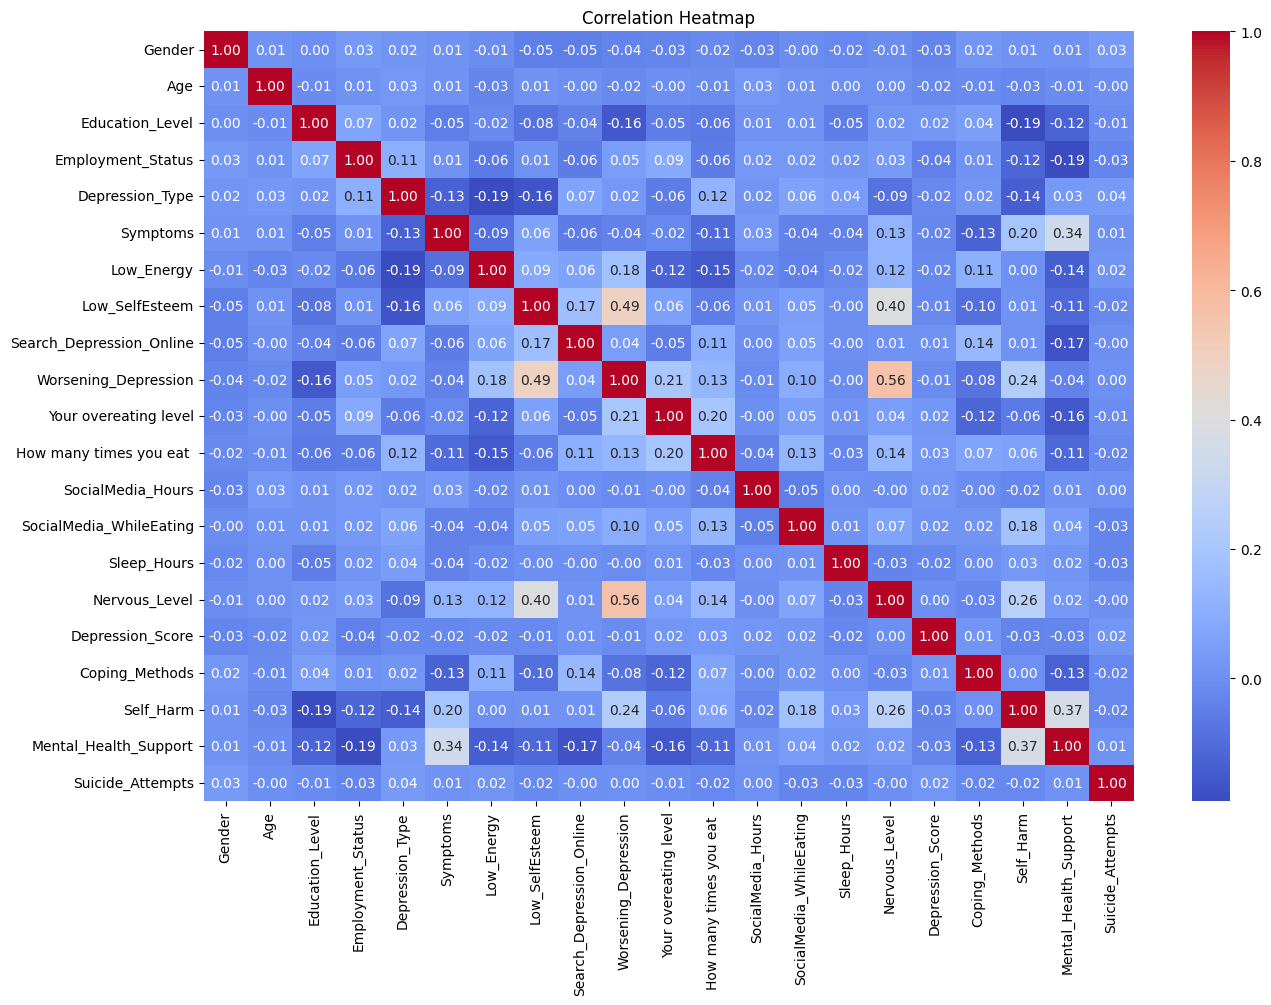

In [ ]:
plt.figure(figsize=(15, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png')

## **Visualizing the Target Variable (Depression Score)**
This block examines the distribution of depression scores and how they vary by gender.

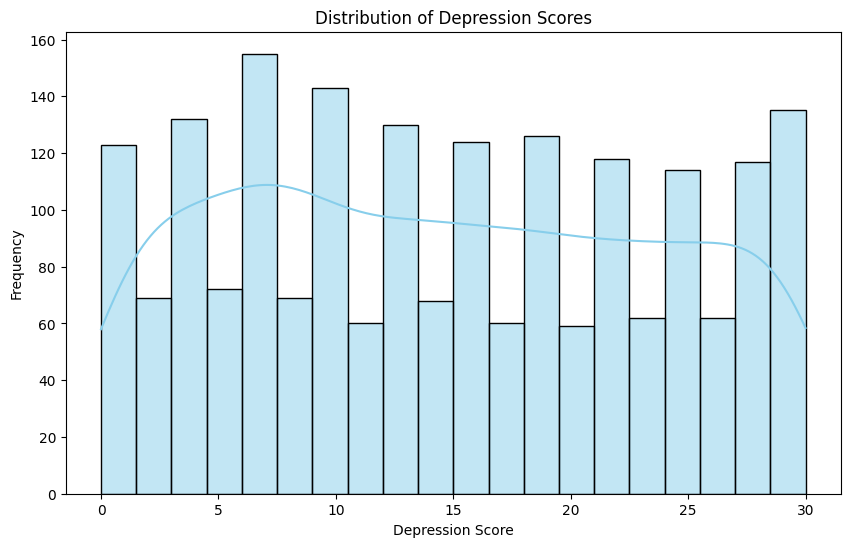

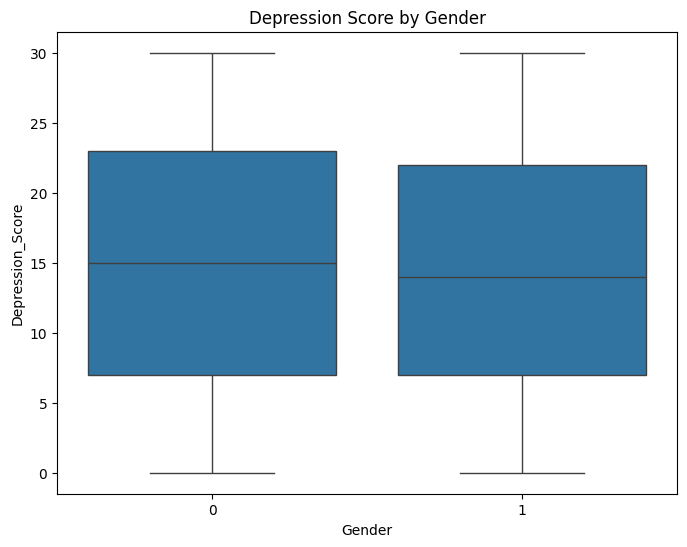

In [ ]:
# Distribution of Depression Scores
plt.figure(figsize=(10, 6))
sns.histplot(df['Depression_Score'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of Depression Scores')
plt.xlabel('Depression Score')
plt.ylabel('Frequency')
plt.savefig('depression_score_distribution.png')

# Boxplot of Depression Score by Gender
plt.figure(figsize=(8, 6))
sns.boxplot(x='Gender', y='Depression_Score', data=df)
plt.title('Depression Score by Gender')
plt.savefig('depression_by_gender.png')

## **Target Variable Distribution after grouping**

In this we group together depression score

/tmp/ipython-input-88143689.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=plot_df, x='Label', palette='magma',


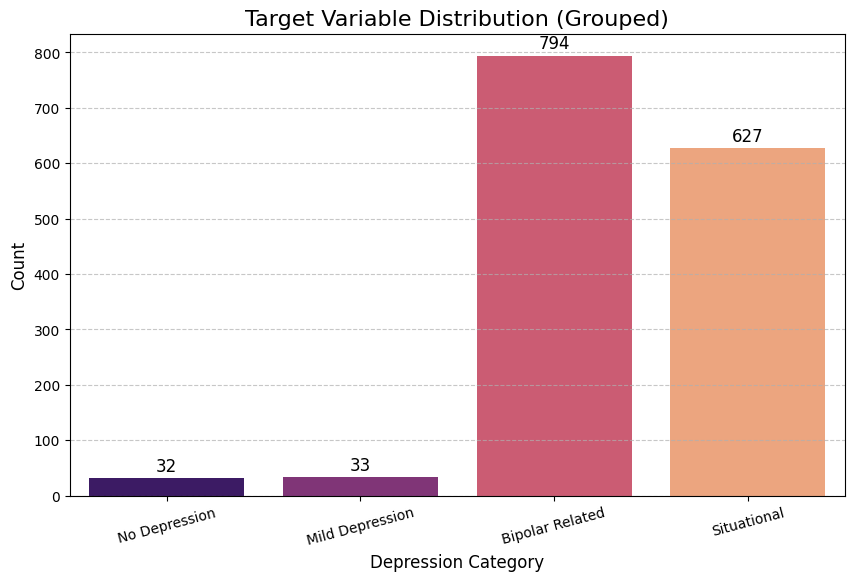

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create the 'depression_score_grouped' column
# Define conditions
conditions = [
    (df['Depression_Type'] == 0),
    (df['Depression_Type'] == 1),
    (df['Depression_Type'] >= 3) & (df['Depression_Type'] <= 8),
    (df['Depression_Type'] == 9)
]

# Define corresponding values: 0->0, 1->1, 3-8->2, 9->3
choices = [0, 1, 2, 3]

# Apply logic (values not in conditions will be set to NaN or a default value)
df['depression_score_grouped'] = np.select(conditions, choices, default=np.nan)

# Drop rows that don't fall into these categories if necessary
# df = df.dropna(subset=['depression_score_grouped'])

# 2. Create the target distribution graph
plt.figure(figsize=(10, 6))

# Define readable labels for the plot
labels = {
    0.0: 'No Depression',
    1.0: 'Mild Depression',
    2.0: 'Bipolar Related',
    3.0: 'Situational'
}

# Map the numbers to labels for the X-axis
plot_df = df.dropna(subset=['depression_score_grouped']).copy()
plot_df['Label'] = plot_df['depression_score_grouped'].map(labels)

# Plotting
ax = sns.countplot(data=plot_df, x='Label', palette='magma',
                   order=['No Depression', 'Mild Depression', 'Bipolar Related', 'Situational'])

# Add frequency counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Target Variable Distribution (Grouped)', fontsize=16)
plt.xlabel('Depression Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## **Visualizing the Relationship Between Age and Sleep**

To explore how age correlates with sleep habits across different depression severity levels, we use a **Scatterplot**. This visualization helps identify patterns such as:
* **Age Trends:** Whether sleep duration tends to increase or decrease as patients get older.
* **Depression Clusters:** How specific `Depression_Score` levels are distributed across the age and sleep spectrum.

**Variables:**
* **X-axis:** `Age` (Numerical)
* **Y-axis:** `Sleep_Hours` (Numerical)
* **Color (Hue):** `Depression_Score` (Categorical)

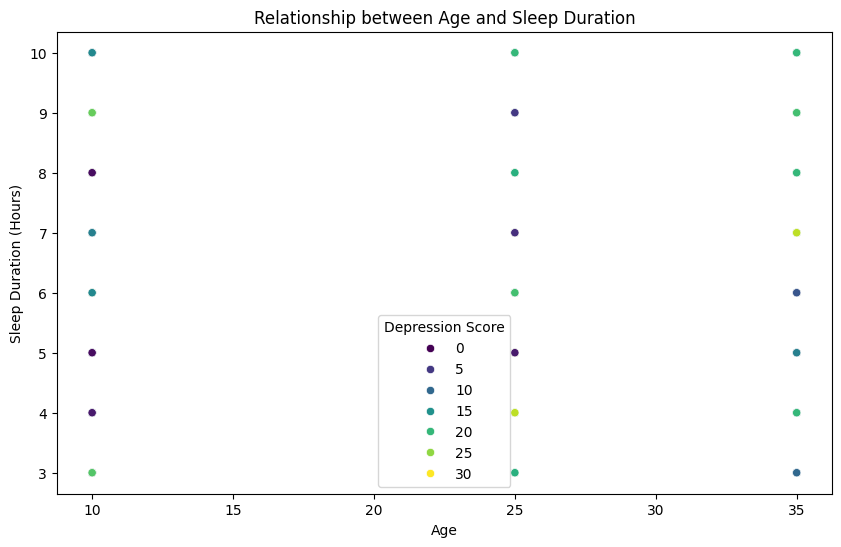

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Replace 'Age' and 'Sleep Duration' with your actual column names
# 'hue' adds color based on a categorical column like 'Depression' or 'Status'
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Sleep_Hours', hue='Depression_Score', palette='viridis')

plt.title('Relationship between Age and Sleep Duration')
plt.xlabel('Age')
plt.ylabel('Sleep Duration (Hours)')
plt.legend(title='Depression Score')
plt.show()

In [ ]:
df.head()

,Gender,Age,Education_Level,Employment_Status,Depression_Type,Symptoms,Low_Energy,Low_SelfEsteem,Search_Depression_Online,Worsening_Depression,...,SocialMedia_Hours,SocialMedia_WhileEating,Sleep_Hours,Nervous_Level,Depression_Score,Coping_Methods,Self_Harm,Mental_Health_Support,Suicide_Attempts,depression_score_grouped
0,1,25,2,3,5,11,1,1,1,1,...,10,3,10,10,10,11,0,0,0,2.0
1,1,25,2,2,5,0,1,1,0,1,...,8,3,4,10,10,0,0,1,0,2.0
2,1,25,2,3,2,5,1,1,1,1,...,10,3,4,10,10,0,1,1,1,NaN
3,0,25,2,2,6,7,0,1,0,1,...,4,3,3,10,10,5,1,1,1,2.0
4,1,25,2,2,6,5,0,0,0,0,...,3,3,7,1,3,0,0,0,0,2.0


# **Model Pre-processing & Feature Selection**
This section prepares the dataset for the machine learning pipeline. We focus on transforming the raw data into a format that the SVM, Logistic Regression, and KNN models can process effectively.

1. **Target Cleaning:** We remove any rows missing the target label (depression_score_grouped) to ensure the model has a clear ground truth to learn from.

2. **Feature Selection & Leakage Prevention:** To build a model that predicts based on lifestyle and behavioral patterns, we explicitly drop "leaky" columns.

Clinical Indicators: We remove columns like Depression_Score and Symptoms. Including these would make the model's job "too easy" (achieving 100% accuracy) because they are effectively the same as the target variable.

Resulting Features: The model is forced to find relationships in variables like Nervous_Level, Sleep_Hours, and Employment_Status.

3. **Stratified Train-Test Split:** We split the data into 80% training and 20% testing.

Stratification: We use stratify=y to ensure that the class distribution (the ratio of different depression levels) remains identical in both the training and testing sets. This is crucial for handling imbalanced data.

4. **Feature Scaling :**
Models like SVM and KNN calculate the distance between data points.

Standardization: We apply StandardScaler to transform all features to have a mean of 0 and a standard deviation of 1. Without this, a feature like Age (range 0–100) would unfairly outweigh a feature like Gender (range 0–1).

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Clean Target Variable
# Remove any rows where your grouped target is NaN
df_final = df.dropna(subset=['depression_score_grouped']).copy()

# 2. Define Features (X) and Target (y)
# We drop direct clinical results/scores to ensure the model learns lifestyle patterns
leaky_cols = [
    'Depression_Type', 'Depression_Score', 'Symptoms',
    'depression_score_grouped', 'Your overeating level'
]
X = df_final.drop(columns=[col for col in leaky_cols if col in df_final.columns])
y = df_final['depression_score_grouped'].astype(int)

# 3. Train-Test Split (80/20)
# Stratify=y ensures the imbalance is preserved in both sets for fair testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Final Feature Set: {list(X.columns)}")
print(f"Dataset size: {len(df_final)} samples")

Final Feature Set: ['Gender', 'Age', 'Education_Level', 'Employment_Status', 'Low_Energy', 'Low_SelfEsteem', 'Search_Depression_Online', 'Worsening_Depression', 'How many times you eat ', 'SocialMedia_Hours', 'SocialMedia_WhileEating', 'Sleep_Hours', 'Nervous_Level', 'Coping_Methods', 'Self_Harm', 'Mental_Health_Support', 'Suicide_Attempts']
Dataset size: 1486 samples


# **Model Training & Evaluation**
This stage executes the training pipeline for three classifiers: Logistic Regression, KNN, and SVM.

## 1. **Workflow**
Scaling: Standardizes features to ensure distance-based models

(SVM) function correctly.

Optimization: Uses max_iter=1000 for Logistic Regression to ensure convergence.

Monitoring: Tracks training and inference latency to assess efficiency.

## 2. **Evaluation Metrics**
Models are assessed using weighted metrics to account for class distribution:

Accuracy & F1-Score: Measures overall correctness and the balance between Precision and Recall.

Precision & Recall: Evaluates the model's ability to minimize false positives versus catching all true positives.

## 3. **Visualization**
Confusion Matrices: Heatmaps pinpointing specific classification errors across labels.

ROC Curve (AUC): A comparative plot of model sensitivity, where higher Area Under the Curve indicates better class separation.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


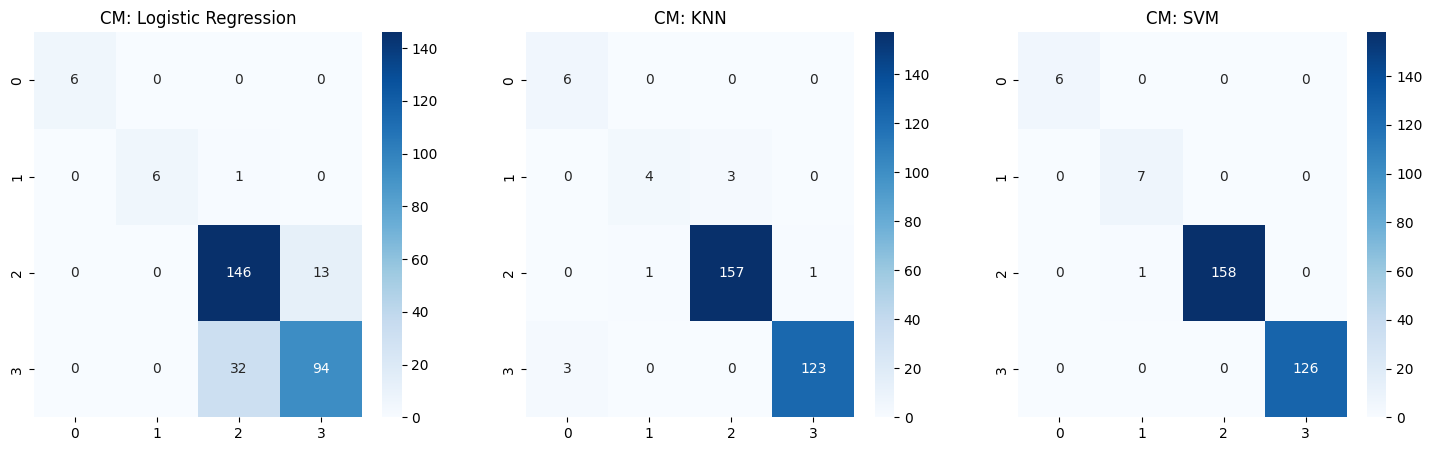

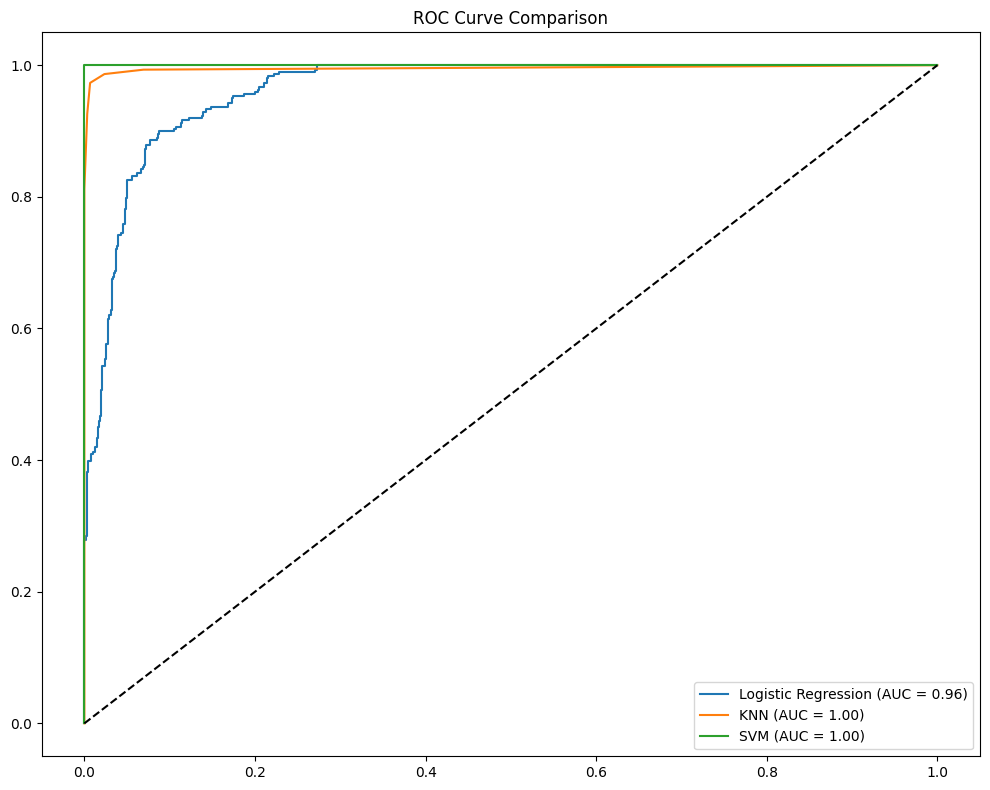


       MODEL COMPARISON SUMMARY
                     Accuracy  Precision    Recall  F1-Score  Train Time (s)  \
Model                                                                          
SVM                  0.996644   0.997064  0.996644  0.996751          0.6618   
KNN                  0.973154   0.975177  0.973154  0.973015          0.0011   
Logistic Regression  0.845638   0.850264  0.845638  0.843919          0.0221   

                     Test Time (s)  
Model                               
SVM                         0.0399  
KNN                         0.0472  
Logistic Regression         0.0009  


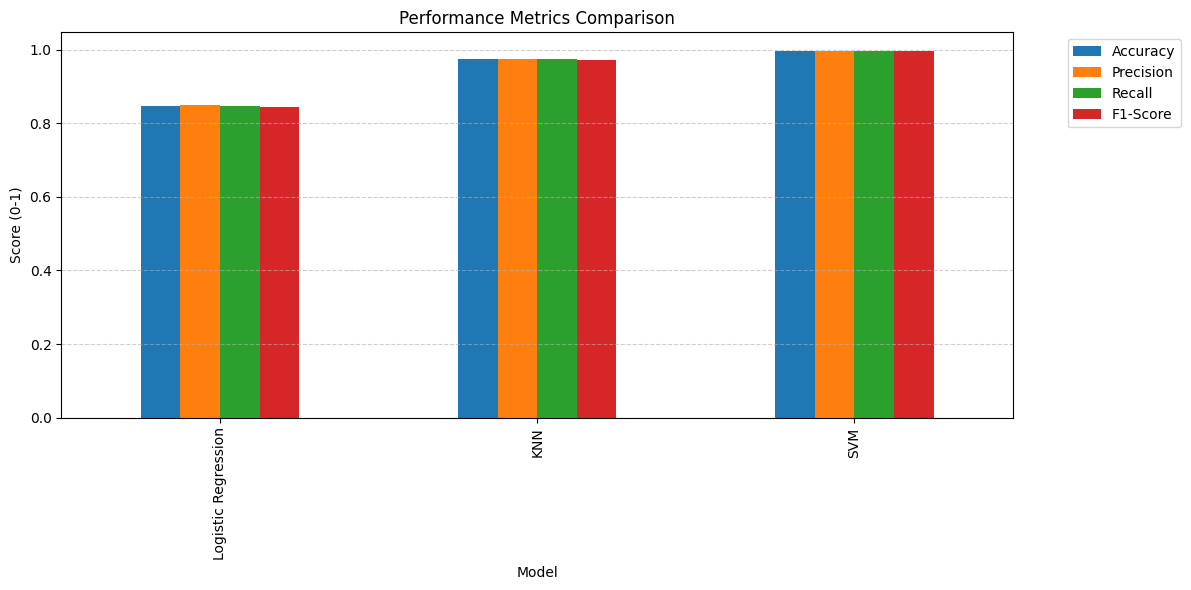

In [ ]:
from sklearn.neighbors import KNeighborsClassifier # New Import

# 1. Scaling & Logic Setup
# Note: Scaling is CRITICAL for KNN because it relies on distance (Euclidean)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, multi_class='ovr', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5), # Replaced Gradient Boosting
    "SVM": SVC(probability=True, random_state=42)
}

# 2. Training and Evaluation
results = []
classes = np.unique(y_train)
y_test_bin = label_binarize(y_test, classes=classes)

fig_cm, axes_cm = plt.subplots(1, 3, figsize=(18, 5))
fig_roc, ax_roc = plt.subplots(figsize=(10, 8))

for idx, (name, model) in enumerate(models.items()):
    start_train = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start_train

    start_test = time.time()
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)
    test_time = time.time() - start_test

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, y_pred, average='weighted', zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, average='weighted', zero_division=0),
        "Train Time (s)": round(train_time, 4),
        "Test Time (s)": round(test_time, 4)
    })

    # Visuals: Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[idx])
    axes_cm[idx].set_title(f'CM: {name}')

    # Visuals: ROC Curve
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
    ax_roc.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})')

ax_roc.plot([0, 1], [0, 1], 'k--')
ax_roc.set_title('ROC Curve Comparison')
ax_roc.legend()
plt.tight_layout()
plt.show()

# --- 3. SUMMARIZED EVALUATION METRICS ---
df_results = pd.DataFrame(results).set_index("Model")

print("\n" + "="*40)
print("       MODEL COMPARISON SUMMARY")
print("="*40)
# Sorting by F1-Score to see the best performing model at the top
print(df_results.sort_values(by="F1-Score", ascending=False))

# Visualization of Summary
df_results[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(kind='bar', figsize=(12, 6))
plt.title('Performance Metrics Comparison')
plt.ylabel('Score (0-1)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## **Hyperparameter Optimization using Optuna**

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 3.6 MB/s eta 0:00:00


[I 2026-02-21 16:20:27,603] A new study created in memory with name: no-name-2f8bcfd2-5977-4943-a652-bc6e4204b613


Starting Hyperparameter Optimization...


[I 2026-02-21 16:20:36,140] Trial 0 finished with value: 0.8318178912198458 and parameters: {'classifier': 'SVM', 'svc_c': 1.5128389767565167, 'svc_kernel': 'linear'}. Best is trial 0 with value: 0.8318178912198458.
[I 2026-02-21 16:20:36,482] Trial 1 finished with value: 0.8081224380547587 and parameters: {'classifier': 'LogReg', 'lr_c': 0.30492587669435867}. Best is trial 0 with value: 0.8318178912198458.
[I 2026-02-21 16:20:36,670] Trial 2 finished with value: 0.6243848716515485 and parameters: {'classifier': 'LogReg', 'lr_c': 0.0009304760262368389}. Best is trial 0 with value: 0.8318178912198458.
[I 2026-02-21 16:20:36,942] Trial 3 finished with value: 0.9799734593868135 and parameters: {'classifier': 'KNN', 'knn_k': 15, 'knn_weights': 'distance'}. Best is trial 3 with value: 0.9799734593868135.
[I 2026-02-21 16:20:37,081] Trial 4 finished with value: 0.9629640028149694 and parameters: {'classifier': 'KNN', 'knn_k': 4, 'knn_weights': 'uniform'}. Best is trial 3 with value: 0.979973


Optimization Complete. Best CV Score: 1.0000


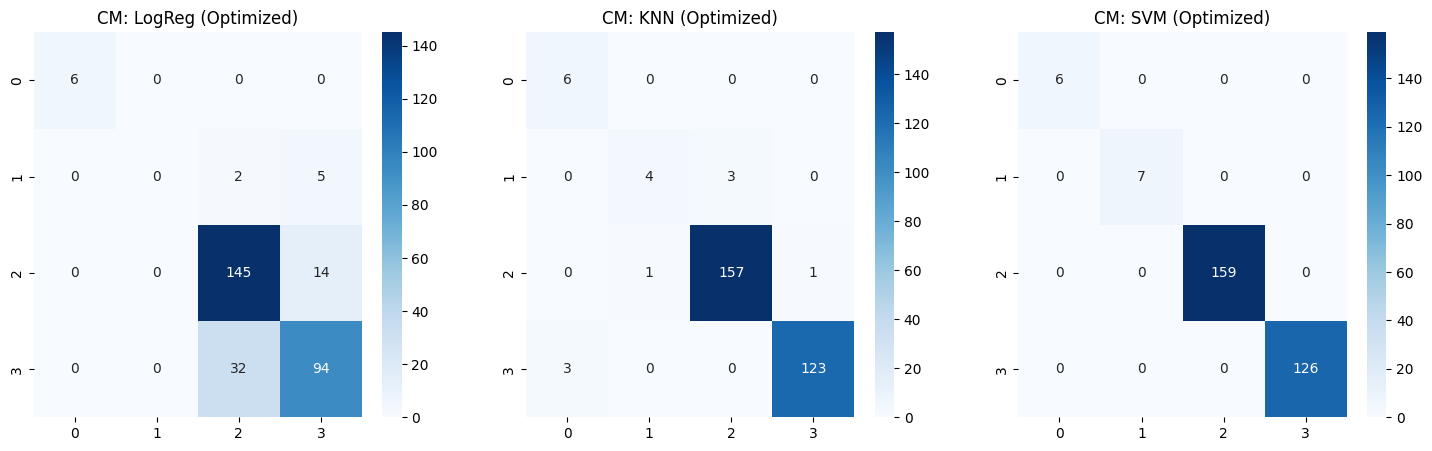

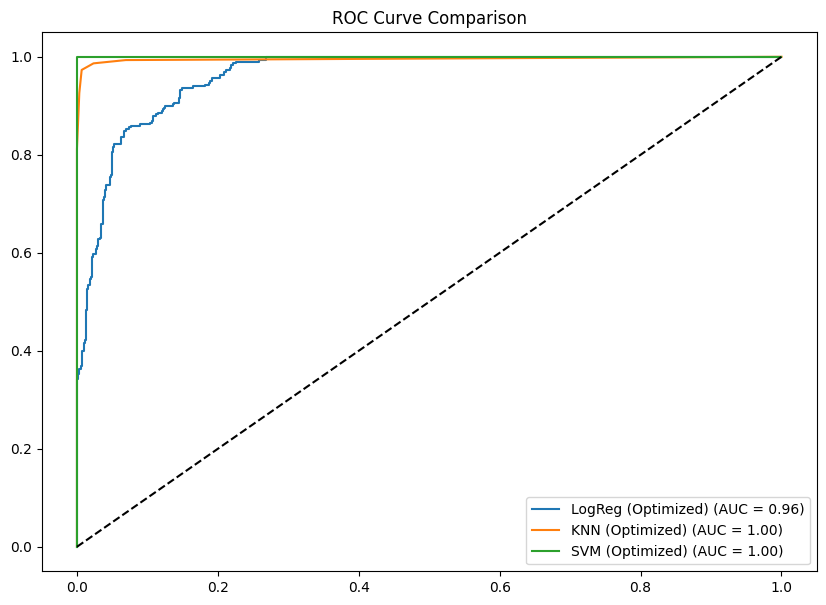


             FINAL PERFORMANCE SUMMARY
                    Accuracy  Precision    Recall  F1-Score  Train Time (s)  \
Model                                                                         
SVM (Optimized)     1.000000   1.000000  1.000000  1.000000          0.4375   
KNN (Optimized)     0.973154   0.975177  0.973154  0.973015          0.0112   
LogReg (Optimized)  0.822148   0.804071  0.822148  0.810514          0.1034   

                    Test Time (s)  
Model                              
SVM (Optimized)            0.0193  
KNN (Optimized)            0.0280  
LogReg (Optimized)         0.0009  


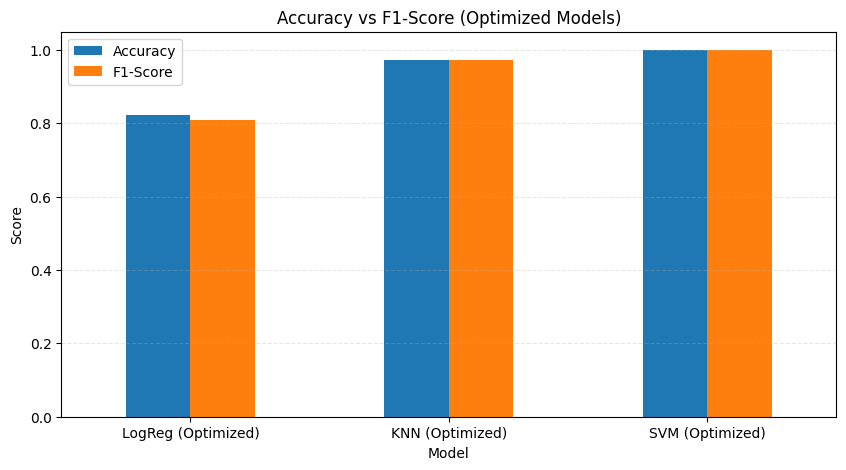

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import optuna
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, auc)

# ---3. OPTUNA OPTIMIZATION PHASE ---
print("Starting Hyperparameter Optimization...")

def objective(trial):
    classifier_name = trial.suggest_categorical("classifier", ["LogReg", "KNN", "SVM"])

    if classifier_name == "LogReg":
        c_lr = trial.suggest_float("lr_c", 1e-4, 1.0, log=True)
        model = LogisticRegression(C=c_lr, max_iter=1000, random_state=42)

    elif classifier_name == "KNN":
        k = trial.suggest_int("knn_k", 3, 25)
        weights = trial.suggest_categorical("knn_weights", ["uniform", "distance"])
        model = KNeighborsClassifier(n_neighbors=k, weights=weights)

    else: # SVM
        c_svc = trial.suggest_float("svc_c", 1e-3, 5.0, log=True)
        kernel = trial.suggest_categorical("svc_kernel", ["linear", "rbf"])
        model = SVC(C=c_svc, kernel=kernel, probability=True, random_state=42)

    # Use 5-fold CV to prevent "perfect" accuracy on a single split
    score = cross_val_score(model, X_train_scaled, y_train, n_jobs=-1, cv=5, scoring='f1_weighted')
    return score.mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print(f"\nOptimization Complete. Best CV Score: {study.best_value:.4f}")
bp = study.best_params

# --- 3. INITIALIZE OPTIMIZED MODELS ---
models = {
    "LogReg (Optimized)": LogisticRegression(
        C=bp.get("lr_c", 0.1) if bp['classifier']=='LogReg' else 0.1,
        max_iter=1000, random_state=42
    ),
    "KNN (Optimized)": KNeighborsClassifier(
        n_neighbors=bp.get("knn_k", 5) if bp['classifier']=='KNN' else 5,
        weights=bp.get("knn_weights", "uniform") if bp['classifier']=='KNN' else "uniform"
    ),
    "SVM (Optimized)": SVC(
        C=bp.get("svc_c", 1.0) if bp['classifier']=='SVM' else 1.0,
        kernel=bp.get("svc_kernel", "rbf") if bp['classifier']=='SVM' else "rbf",
        probability=True, random_state=42
    )
}

# --- 4. FINAL TRAINING, EVALUATION & VISUALS ---
results = []
fig_cm, axes_cm = plt.subplots(1, 3, figsize=(18, 5))
fig_roc, ax_roc = plt.subplots(figsize=(10, 7))

for idx, (name, model) in enumerate(models.items()):
    # Timing and Fitting
    start_train = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start_train

    start_test = time.time()
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)
    test_time = time.time() - start_test

    # Metric Calculation
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, y_pred, average='weighted', zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, average='weighted', zero_division=0),
        "Train Time (s)": round(train_time, 4),
        "Test Time (s)": round(test_time, 4)
    })

    # Visuals: Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[idx])
    axes_cm[idx].set_title(f'CM: {name}')

    # Visuals: ROC Curve
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
    ax_roc.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})')

ax_roc.plot([0, 1], [0, 1], 'k--')
ax_roc.set_title('ROC Curve Comparison')
ax_roc.legend()
plt.show()

# --- 5. SUMMARIZED EVALUATION METRICS ---
df_results = pd.DataFrame(results).set_index("Model")
print("\n" + "="*50)
print("             FINAL PERFORMANCE SUMMARY")
print("="*50)
print(df_results.sort_values(by="F1-Score", ascending=False))

# Performance Bar Chart
df_results[['Accuracy', 'F1-Score']].plot(kind='bar', figsize=(10, 5))
plt.title('Accuracy vs F1-Score (Optimized Models)')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

In [ ]:
from sklearn.model_selection import StratifiedKFold

# 1. Check for high correlation (Potential Leakage)
# If a feature has >0.95 correlation with the target, it might be 'cheating'
correlation_matrix = pd.concat([X_train, y_train], axis=1).corr()
target_col = correlation_matrix.columns[-1]
potential_leakage = correlation_matrix[target_col][abs(correlation_matrix[target_col]) > 0.95]
print("Potential Leakage Features:\n", potential_leakage)

# 2. Robust Objective Function
def objective(trial):
    classifier_name = trial.suggest_categorical("classifier", ["LogReg", "KNN", "SVM"])

    # We use a smaller C range to force the model to be 'simpler' (Regularization)
    if classifier_name == "LogReg":
        c_lr = trial.suggest_float("lr_c", 1e-5, 0.1, log=True) # Lower C = More Regularization
        model = LogisticRegression(C=c_lr, max_iter=1000, random_state=42)
    elif classifier_name == "KNN":
        k = trial.suggest_int("knn_k", 10, 30) # Higher K = Smoother boundary
        model = KNeighborsClassifier(n_neighbors=k)
    else:
        c_svc = trial.suggest_float("svc_c", 1e-4, 0.5, log=True) # Avoid high C values
        model = SVC(C=c_svc, kernel='rbf', probability=True, random_state=42)

    # Stratified CV ensures class proportions are kept and results are honest
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(model, X_train_scaled, y_train, n_jobs=-1, cv=cv, scoring='f1_weighted')

    return score.mean()



Potential Leakage Features:
 depression_score_grouped    1.0
Name: depression_score_grouped, dtype: float64


[I 2026-02-21 16:21:32,715] A new study created in memory with name: no-name-ca4bfbad-13b4-4348-aae3-87aa39263d44


Starting Hyperparameter Optimization...


[I 2026-02-21 16:21:34,156] Trial 0 finished with value: 0.37237299187992284 and parameters: {'classifier': 'SVM', 'svc_c': 0.0025733757721693286, 'svc_kernel': 'rbf'}. Best is trial 0 with value: 0.37237299187992284.
[I 2026-02-21 16:21:34,271] Trial 1 finished with value: 0.9601889801128729 and parameters: {'classifier': 'KNN', 'knn_k': 22, 'knn_weights': 'distance'}. Best is trial 1 with value: 0.9601889801128729.
[I 2026-02-21 16:21:34,503] Trial 2 finished with value: 0.7856354930154072 and parameters: {'classifier': 'LogReg', 'lr_c': 0.053163843744579664}. Best is trial 1 with value: 0.9601889801128729.
[I 2026-02-21 16:21:34,680] Trial 3 finished with value: 0.9652799452904104 and parameters: {'classifier': 'KNN', 'knn_k': 19, 'knn_weights': 'distance'}. Best is trial 3 with value: 0.9652799452904104.
[I 2026-02-21 16:21:34,822] Trial 4 finished with value: 0.6320223452412561 and parameters: {'classifier': 'LogReg', 'lr_c': 0.0010593518747367366}. Best is trial 3 with value: 0.9


Optimization Complete. Best CV Score: 0.9814


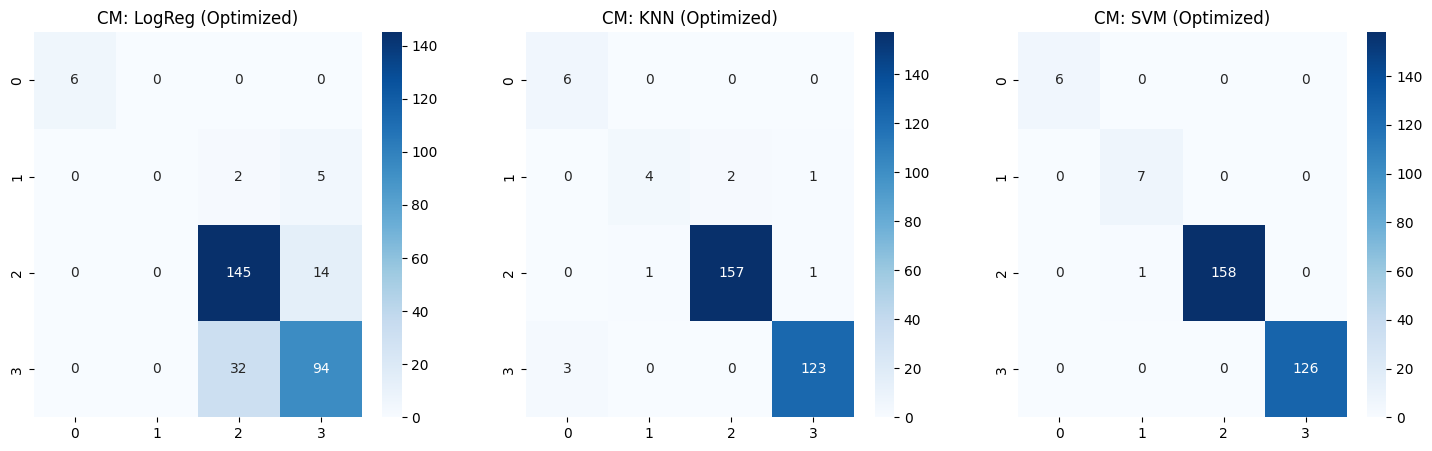

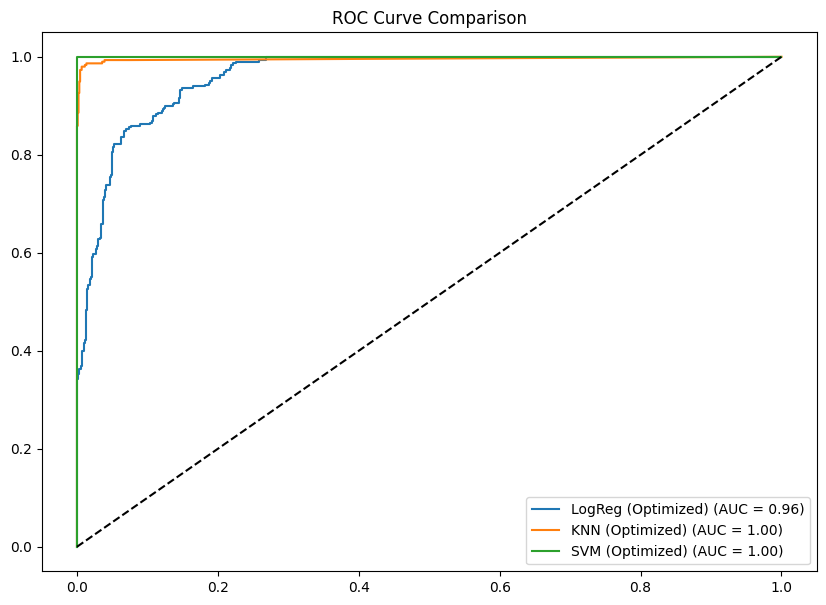


             FINAL PERFORMANCE SUMMARY
                    Accuracy  Precision    Recall  F1-Score  Train Time (s)  \
Model                                                                         
SVM (Optimized)     0.996644   0.997064  0.996644  0.996751          0.2591   
KNN (Optimized)     0.973154   0.975114  0.973154  0.973009          0.0009   
LogReg (Optimized)  0.822148   0.804071  0.822148  0.810514          0.0191   

                    Test Time (s)  
Model                              
SVM (Optimized)            0.0222  
KNN (Optimized)            0.0070  
LogReg (Optimized)         0.0008  


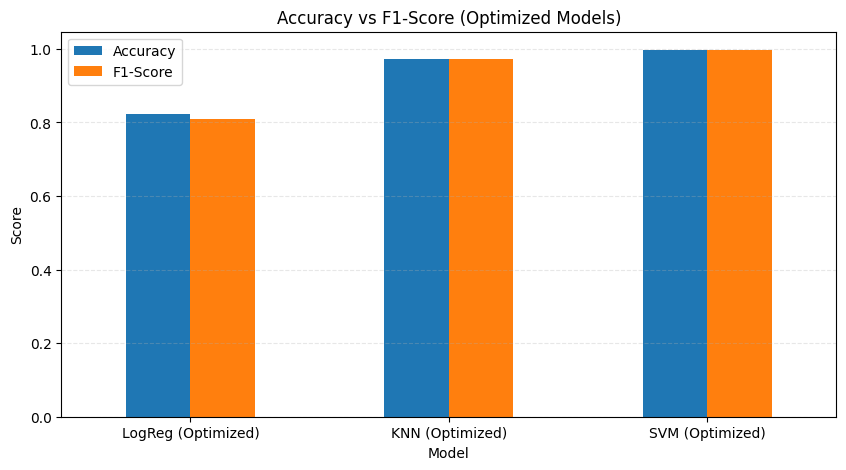

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import optuna
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, auc)

# ---3. OPTUNA OPTIMIZATION PHASE ---
print("Starting Hyperparameter Optimization...")

def objective(trial):
    classifier_name = trial.suggest_categorical("classifier", ["LogReg", "KNN", "SVM"])

    if classifier_name == "LogReg":
        c_lr = trial.suggest_float("lr_c", 1e-4, 1.0, log=True)
        model = LogisticRegression(C=c_lr, max_iter=1000, random_state=42)

    elif classifier_name == "KNN":
        k = trial.suggest_int("knn_k", 3, 25)
        weights = trial.suggest_categorical("knn_weights", ["uniform", "distance"])
        model = KNeighborsClassifier(n_neighbors=k, weights=weights)

    else: # SVM
        c_svc = trial.suggest_float("svc_c", 1e-3, 5.0, log=True)
        kernel = trial.suggest_categorical("svc_kernel", ["linear", "rbf"])
        model = SVC(C=c_svc, kernel=kernel, probability=True, random_state=42)

    # Use 5-fold CV to prevent "perfect" accuracy on a single split
    score = cross_val_score(model, X_train_scaled, y_train, n_jobs=-1, cv=5, scoring='f1_weighted')
    return score.mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print(f"\nOptimization Complete. Best CV Score: {study.best_value:.4f}")
bp = study.best_params

# --- 3. INITIALIZE OPTIMIZED MODELS ---
models = {
    "LogReg (Optimized)": LogisticRegression(
        C=bp.get("lr_c", 0.1) if bp['classifier']=='LogReg' else 0.1,
        max_iter=1000, random_state=42
    ),
    "KNN (Optimized)": KNeighborsClassifier(
        n_neighbors=bp.get("knn_k", 5) if bp['classifier']=='KNN' else 5,
        weights=bp.get("knn_weights", "uniform") if bp['classifier']=='KNN' else "uniform"
    ),
    "SVM (Optimized)": SVC(
        C=bp.get("svc_c", 1.0) if bp['classifier']=='SVM' else 1.0,
        kernel=bp.get("svc_kernel", "rbf") if bp['classifier']=='SVM' else "rbf",
        probability=True, random_state=42
    )
}

# --- 4. FINAL TRAINING, EVALUATION & VISUALS ---
results = []
fig_cm, axes_cm = plt.subplots(1, 3, figsize=(18, 5))
fig_roc, ax_roc = plt.subplots(figsize=(10, 7))

for idx, (name, model) in enumerate(models.items()):
    # Timing and Fitting
    start_train = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start_train

    start_test = time.time()
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)
    test_time = time.time() - start_test

    # Metric Calculation
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, y_pred, average='weighted', zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, average='weighted', zero_division=0),
        "Train Time (s)": round(train_time, 4),
        "Test Time (s)": round(test_time, 4)
    })

    # Visuals: Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[idx])
    axes_cm[idx].set_title(f'CM: {name}')

    # Visuals: ROC Curve
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
    ax_roc.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})')

ax_roc.plot([0, 1], [0, 1], 'k--')
ax_roc.set_title('ROC Curve Comparison')
ax_roc.legend()
plt.show()

# --- 5. SUMMARIZED EVALUATION METRICS ---
df_results = pd.DataFrame(results).set_index("Model")
print("\n" + "="*50)
print("             FINAL PERFORMANCE SUMMARY")
print("="*50)
print(df_results.sort_values(by="F1-Score", ascending=False))

# Performance Bar Chart
df_results[['Accuracy', 'F1-Score']].plot(kind='bar', figsize=(10, 5))
plt.title('Accuracy vs F1-Score (Optimized Models)')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

## **K-Fold Cross Validation**

Running Comprehensive K-Fold CV...

             K-FOLD CROSS-VALIDATION STATISTICAL SUMMARY
                    Accuracy Mean  Accuracy Std  Precision Mean  \
Model                                                             
LogReg (Optimized)         0.7896        0.0072          0.7729   
KNN (Optimized)            0.9781        0.0097          0.9800   
SVM (Optimized)            0.9798        0.0114          0.9871   

                    Precision Std  Recall Mean  Recall Std  F1 Mean  F1 Std  
Model                                                                        
LogReg (Optimized)         0.0074       0.7896      0.0072   0.7810  0.0072  
KNN (Optimized)            0.0088       0.9781      0.0097   0.9785  0.0094  
SVM (Optimized)            0.0068       0.9798      0.0114   0.9822  0.0097  


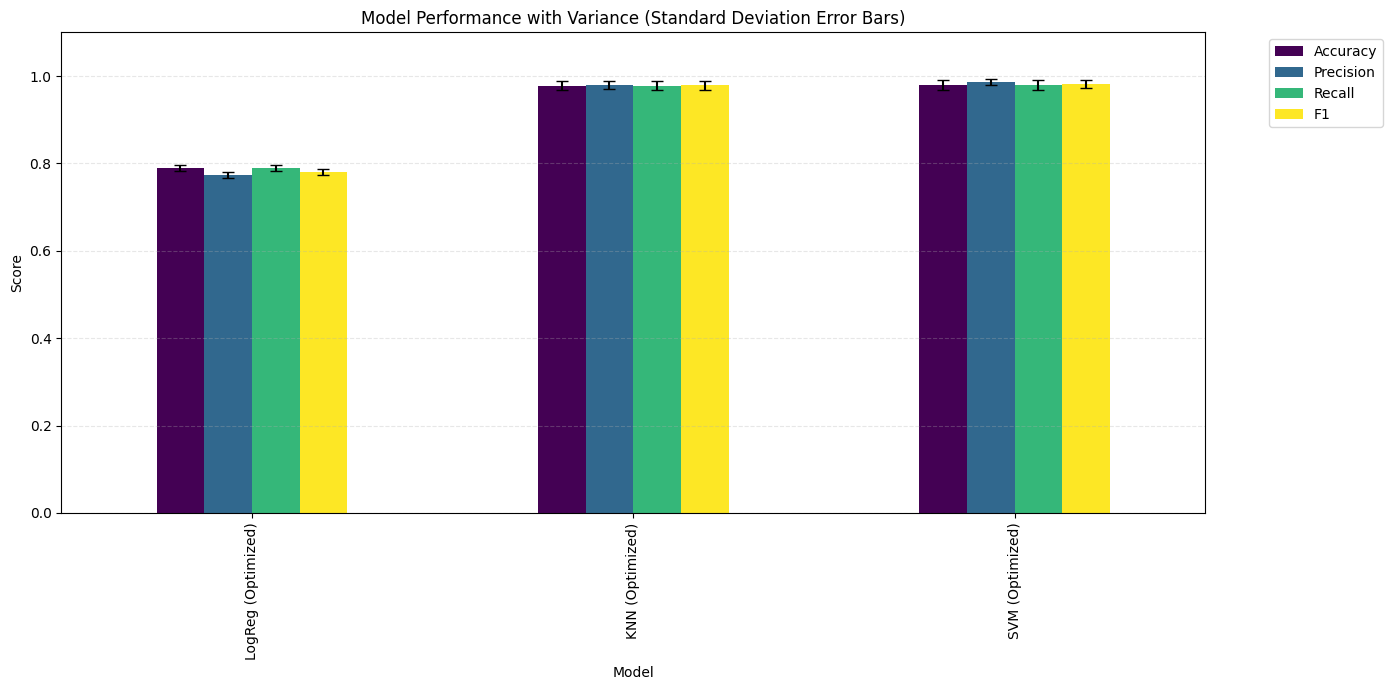

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# 1. Define the K-Fold Strategy (5-fold is industry standard)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define the metrics we want to track
scoring_metrics = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']

cv_summary = []

print("Running Comprehensive K-Fold CV...")

# 2. Perform Cross-Validation for each model
for name, model in models.items():
    # cross_validate runs the model through all folds and captures all scores
    scores = cross_validate(
        model,
        X_train_scaled,
        y_train,
        cv=skf,
        scoring=scoring_metrics,
        n_jobs=-1,
        return_train_score=False
    )

    # Organize the results into a dictionary
    res = {"Model": name}
    for metric in scoring_metrics:
        # Extract the test scores for this specific metric across the 5 folds
        fold_scores = scores[f'test_{metric}']

        # Calculate Mean and Std Dev
        res[f"{metric.capitalize()} Mean"] = np.mean(fold_scores)
        res[f"{metric.capitalize()} Std"] = np.std(fold_scores)

    cv_summary.append(res)

# 3. Format and Display the Results
df_cv = pd.DataFrame(cv_summary).set_index("Model")

# Clean up column names for readability
df_cv.columns = [col.replace('_weighted', '') for col in df_cv.columns]

print("\n" + "="*85)
print("             K-FOLD CROSS-VALIDATION STATISTICAL SUMMARY")
print("="*85)
print(df_cv.round(4))

# 4. Visualization: Performance with Error Bars
# This shows the "reliability" of each model
means = df_cv[[col for col in df_cv.columns if 'Mean' in col]]
stds = df_cv[[col for col in df_cv.columns if 'Std' in col]]

# Rename columns for plotting logic
means.columns = [c.replace(' Mean', '') for c in means.columns]
stds.columns = [c.replace(' Std', '') for c in stds.columns]

means.plot(kind='bar', yerr=stds, figsize=(14, 7), capsize=4, colormap='viridis')
plt.title('Model Performance with Variance (Standard Deviation Error Bars)')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# **Handling Class Imbalance using SMOTE**

Original training shape: (1188, 17)
SMOTE training shape: (2540, 17)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


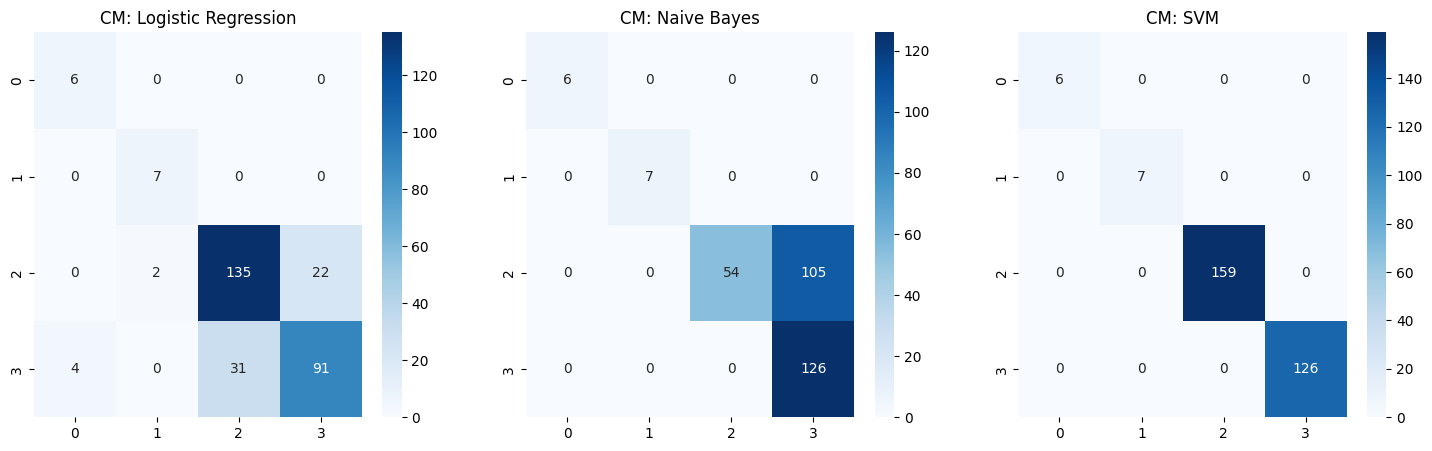

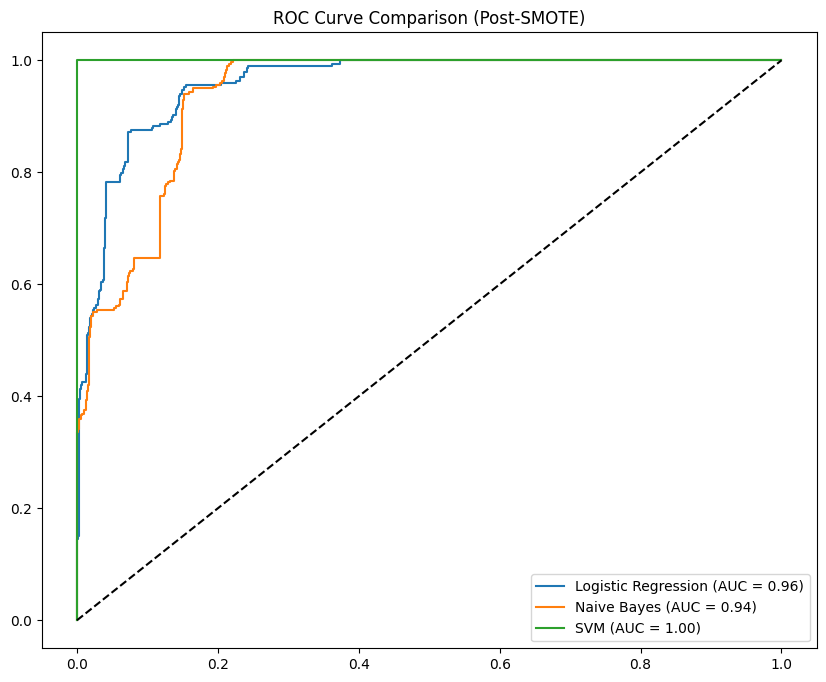


       FINAL PERFORMANCE SUMMARY (POST-SMOTE)
                     Accuracy  Precision    Recall  F1-Score  Train Time (s)  \
Model                                                                          
SVM                  1.000000   1.000000  1.000000  1.000000          0.9323   
Logistic Regression  0.802013   0.804767  0.802013  0.800896          0.1213   
Naive Bayes          0.647651   0.807810  0.647651  0.612620          0.0043   

                     Test Time (s)  
Model                               
SVM                         0.0415  
Logistic Regression         0.0009  
Naive Bayes                 0.0020  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, auc)
from imblearn.over_sampling import SMOTE  # New Import

# 1. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Apply SMOTE to training data ONLY
# This balances the classes by generating synthetic samples
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Original training shape: {X_train_scaled.shape}")
print(f"SMOTE training shape: {X_train_smote.shape}")

# 3. Model Setup
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, multi_class='ovr', random_state=42),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True, random_state=42)
}

# 4. Training and Evaluation
results = []
classes = np.unique(y_train)
y_test_bin = label_binarize(y_test, classes=classes)

fig_cm, axes_cm = plt.subplots(1, 3, figsize=(18, 5))
fig_roc, ax_roc = plt.subplots(figsize=(10, 8))

for idx, (name, model) in enumerate(models.items()):
    # Fit on SMOTE data
    start_train = time.time()
    model.fit(X_train_smote, y_train_smote)
    train_time = time.time() - start_train

    # Predict on ORIGINAL scaled test data
    start_test = time.time()
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)
    test_time = time.time() - start_test

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, y_pred, average='weighted', zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, average='weighted', zero_division=0),
        "Train Time (s)": round(train_time, 4),
        "Test Time (s)": round(test_time, 4)
    })

    # Visuals: Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[idx])
    axes_cm[idx].set_title(f'CM: {name}')

    # Visuals: ROC Curve
    if len(classes) == 2:
        fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
    else:
        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
    ax_roc.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})')

ax_roc.plot([0, 1], [0, 1], 'k--')
ax_roc.set_title("ROC Curve Comparison (Post-SMOTE)")
ax_roc.legend()
plt.show()

# 5. Summarized Evaluation Metrics
df_results = pd.DataFrame(results).set_index("Model")
print("\n" + "="*60)
print("       FINAL PERFORMANCE SUMMARY (POST-SMOTE)")
print("="*60)
print(df_results.sort_values(by="F1-Score", ascending=False))

## **Checking for Model Overfitness**

In [ ]:
# Create a temporary dataframe of your training data
temp_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
temp_df['target'] = y_train.values

# Calculate correlations
corrs = temp_df.corr()['target'].abs().sort_values(ascending=False)

# Features with correlation > 0.9 are suspicious
print("Top Correlated Features (Potential Leakage):")
print(corrs[corrs > 0.9])

Top Correlated Features (Potential Leakage):
target    1.0
Name: target, dtype: float64


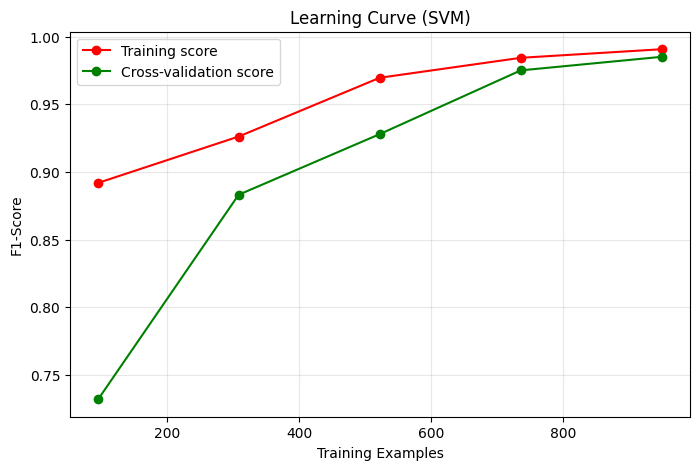

In [ ]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, X, y, name):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='f1_weighted'
    )

    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")
    plt.title(f"Learning Curve ({name})")
    plt.xlabel("Training Examples")
    plt.ylabel("F1-Score")
    plt.legend(loc="best")
    plt.grid(alpha=0.3)
    plt.show()

# Run this for your SVM
plot_learning_curve(models["SVM"], X_train_scaled, y_train, "SVM")

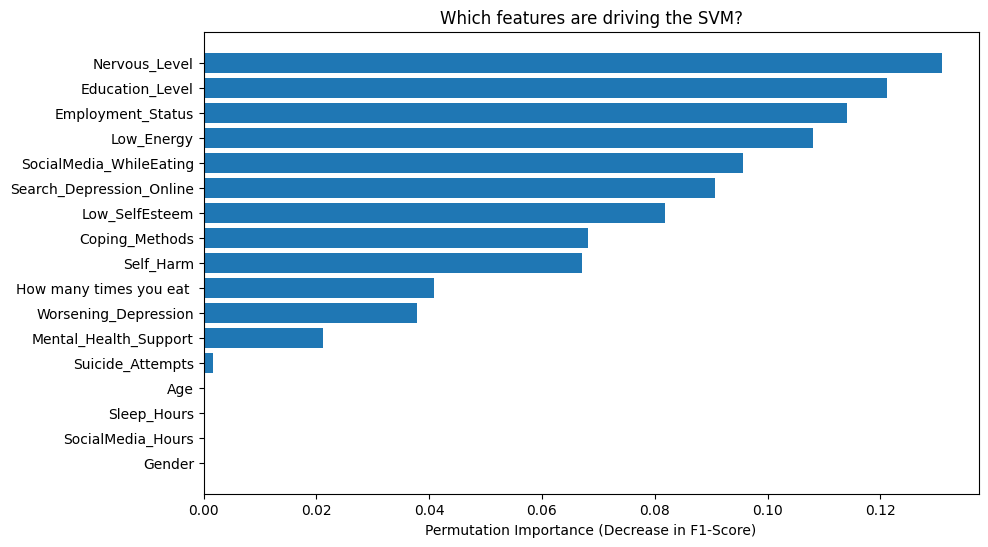

In [ ]:
from sklearn.inspection import permutation_importance

# Calculate importance on the test set
perm_importance = permutation_importance(models["SVM"], X_test_scaled, y_test, n_repeats=10, random_state=42)

# Plotting
sorted_idx = perm_importance.importances_mean.argsort()
plt.figure(figsize=(10, 6))
plt.barh(X_train.columns[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance (Decrease in F1-Score)")
plt.title("Which features are driving the SVM?")
plt.show()

## **Evaluating with SMOTE after resolving issue**

Evaluating Resolved Models with SMOTE + Stratified K-Fold...

             FINAL ROBUST PERFORMANCE SUMMARY
                     Accuracy  F1-Score  Precision  Recall  Std Dev (Acc)
Model                                                                    
Logistic Regression    0.7887    0.7901     0.8001  0.7887         0.0241
Naive Bayes            0.6548    0.6223     0.8102  0.6548         0.0120
SVM (Resolved)         0.9805    0.9831     0.9890  0.9805         0.0072


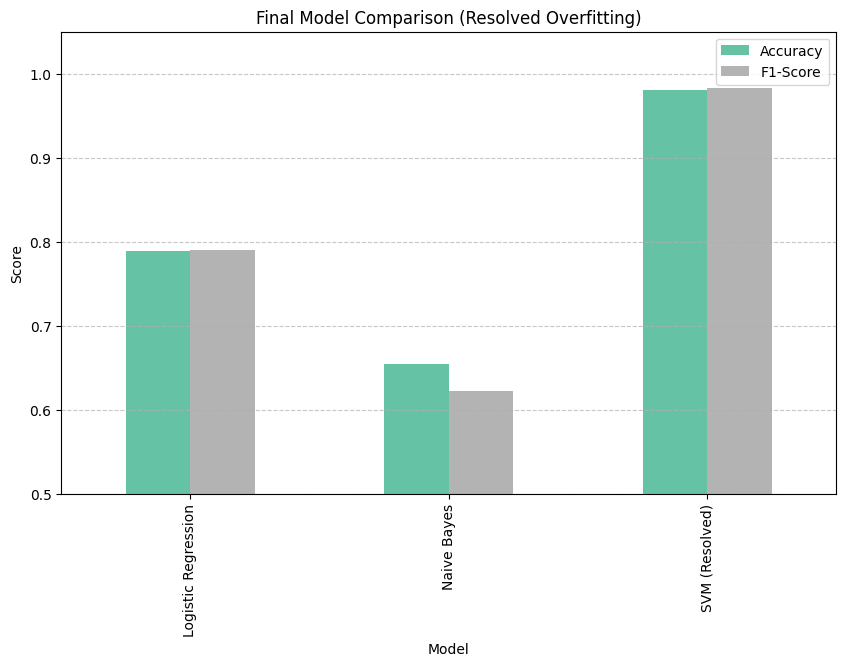

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# --- 1. PREPARATION ---
# Scaling is applied within the pipeline or pre-processed
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # Using full X for CV

# --- 2. THE RESOLVED MODEL SETUP ---
# We use lower C values for SVM and LogReg to prevent the 1.0 overfitting you saw
# We use a Pipeline to ensure SMOTE is only applied to training folds
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(C=0.1, max_iter=1000, random_state=42),
    "Naive Bayes": GaussianNB(),
    "SVM (Resolved)": SVC(C=0.5, kernel='rbf', probability=True, random_state=42)
}

# Metrics to track
scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']
final_results = []

print("Evaluating Resolved Models with SMOTE + Stratified K-Fold...")

# --- 3. EXECUTION LOOP ---
for name, model in models.items():
    # Pipeline ensures: [Scale -> SMOTE -> Train] for every fold correctly
    pipeline = ImbPipeline(steps=[
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])

    cv_results = cross_validate(pipeline, X_scaled, y, cv=skf, scoring=scoring, n_jobs=-1)

    final_results.append({
        "Model": name,
        "Accuracy": np.mean(cv_results['test_accuracy']),
        "F1-Score": np.mean(cv_results['test_f1_weighted']),
        "Precision": np.mean(cv_results['test_precision_weighted']),
        "Recall": np.mean(cv_results['test_recall_weighted']),
        "Std Dev (Acc)": np.std(cv_results['test_accuracy'])
    })

# --- 4. SUMMARY & VISUALIZATION ---
df_final = pd.DataFrame(final_results).set_index("Model")

print("\n" + "="*80)
print("             FINAL ROBUST PERFORMANCE SUMMARY")
print("="*80)
print(df_final.round(4))

# Visualizing the realistic performance
df_final[['Accuracy', 'F1-Score']].plot(kind='bar', figsize=(10, 6), colormap='Set2')
plt.title('Final Model Comparison (Resolved Overfitting)')
plt.ylabel('Score')
plt.ylim(0.5, 1.05) # Focused view
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# **Model Interpretability using SHAP**

  0%|          | 0/50 [00:00<?, ?it/s]

Generating SHAP Summary Plot...


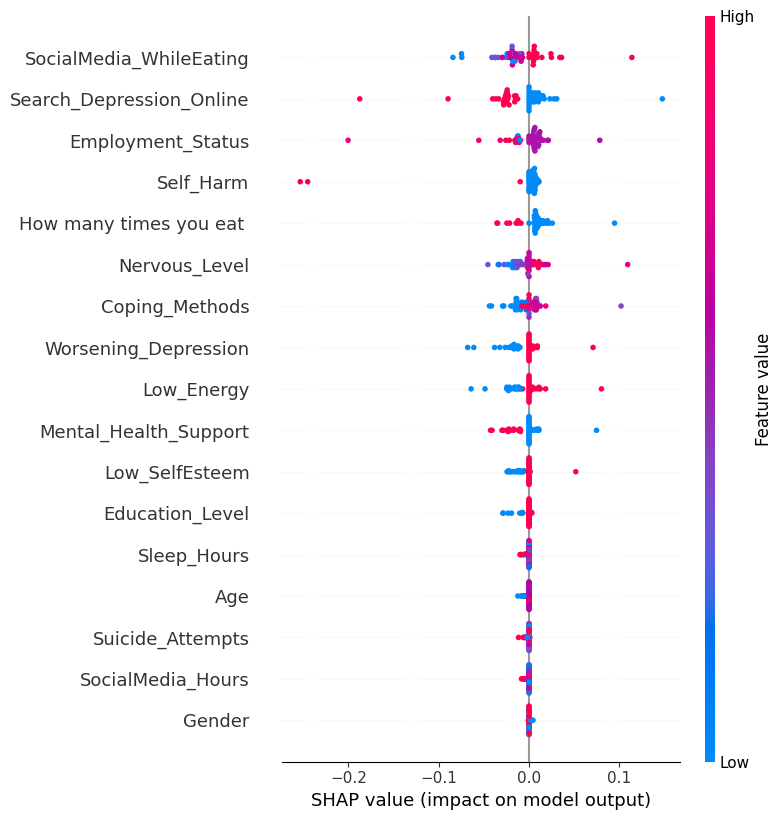

In [ ]:
import shap

# 1. Prepare a background dataset for SHAP
# KernelExplainer needs a summary of the training data to use as a reference point.
# We use 50-100 samples to keep the calculation time reasonable.
X_train_summary = shap.kmeans(X_train_scaled, 50)

# Fit the 'SVM (Resolved)' model explicitly with the SMOTE-resampled training data
# This is necessary because cross_validate in the previous cell fits internal copies, not the original model instance.
models["SVM (Resolved)"].fit(X_train_smote, y_train_smote)

# 2. Initialize the Explainer
# We use the 'probability' output of the SVM (requires probability=True in SVC)
explainer = shap.KernelExplainer(models["SVM (Resolved)"].predict_proba, X_train_summary)

# 3. Calculate SHAP values for a subset of the test set
# Calculating SHAP for the entire test set can take a very long time.
X_test_subset = X_test_scaled[:50]
shap_values = explainer.shap_values(X_test_subset)

# 4. Visualization: Summary Plot
# This shows the global importance of features and their impact direction
# Note: For multi-class, shap_values will be a list. Use shap_values[1] for binary positive class.
print("Generating SHAP Summary Plot...")
# Corrected slicing: shap_values[:, :, 1] extracts SHAP values for class 1 (second class) for all samples and features
shap.summary_plot(shap_values[:, :, 1], X_test_subset, feature_names=X_train.columns)

# 5. Visualization: Force Plot for a single prediction
# This explains why the model made a specific choice for the first person in the test set
shap.initjs()
# Corrected slicing: shap_values[0, :, 1] extracts SHAP values for the first sample (index 0) and class 1
shap.force_plot(explainer.expected_value[1], shap_values[0, :, 1], X_test_subset[0,:], feature_names=X_train.columns)